# Q2 Logistic Regression — Assumption Diagnostics

This notebook is the **diagnostic analysis file** for Q2 using logistic regression on `booking_bool`.

What this file does:
- loads `../data/sample_q2.parquet` and prepares the selected Q2 feature set,
- fits a `statsmodels` logistic model,
- runs assumption-style diagnostics adapted for logistic regression,
- helps explain *why* certain features appear predictive after controlling for position.

How to use it:
1. Run all cells top-to-bottom.
2. Read each diagnostic section as evidence quality checks, not just plots.
3. Use findings to support milestone write-up language about robustness and limitations.

| Section | Diagnostic | What it checks | Linear regression analog |
|---|---|---|---|
| 1 | Pairplot | Pairwise feature relationships + outcome separation | EDA scatterplot matrix |
| 2 | Empirical log-odds plots | Linearity of log-odds assumption | Residual-vs-fitted (linearity) |
| 3 | Model fit | Coefficient estimates and significance | OLS summary |
| 4 | Deviance residuals Q-Q | Residual distribution | Q-Q plot (normality) |
| 5 | Pearson residuals vs fitted | Constant variance / misspecification | Scale-location / residual-vs-fitted |
| 6 | ACF of Pearson residuals | Independence of observations | Autocorrelation / Durbin-Watson |

**Scope:** Diagnostic and exploratory only (not the final production model). For held-out evaluation and model comparison, use the dedicated modeling workflow.

## 0 · Setup and Data Load

We load `data/sample_q2.parquet` — a 10% Bernoulli sample of the full dataset (~993K rows, 54 columns). Because `statsmodels.Logit` is slow at scale, we draw a further **50,000-row random subsample** for diagnostics. Change `N_SAMPLE` if you want to run on more data.

**Features selected:** Low/zero null columns only. High-null columns (`visitor_hist_*`, `comp*`, `srch_query_affinity_score`) are deferred to the final model.

**Transform applied:** `price_usd` is extremely right-skewed (median ~$122, max ~$19M). We apply `log1p` before modeling so the price effect on log-odds is approximately linear.

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns
import matplotlib.pyplot as plt

# ── Configuration ───────────────────────────────────────────────────────────────
N_SAMPLE     = 50_000   # rows for model diagnostics (statsmodels Logit is slow at scale)
PAIRPLOT_N   = 5_000    # smaller subset for pairplot (rendering cost)
RANDOM_STATE = 42

DATA_PATH = '../data/sample_q2.parquet'

# ── Load ────────────────────────────────────────────────────────────────────────
df_full = pd.read_parquet(DATA_PATH)

# ── Feature engineering ─────────────────────────────────────────────────────────
df_full['log_price_usd'] = np.log1p(df_full['price_usd'])

FEATURES = [
    'position',
    'prop_starrating',
    'prop_review_score',
    'prop_brand_bool',
    'prop_location_score1',
    'log_price_usd',
    'prop_log_historical_price',
    'srch_booking_window',
    'srch_length_of_stay',
    'srch_adults_count',
    'srch_saturday_night_bool',
]

# ── Drop nulls, subsample ────────────────────────────────────────────────────────
df_clean = df_full[FEATURES + ['booking_bool', 'srch_id']].dropna()
df = df_clean.sample(n=N_SAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)
df_pair = df.sample(n=PAIRPLOT_N, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'Full parquet rows  : {len(df_full):,}')
print(f'After dropna       : {len(df_clean):,}')
print(f'Diagnostic sample  : {len(df):,}')
print(f'Booking rate       : {df["booking_bool"].mean():.3%}')

Full parquet rows  : 993,210
After dropna       : 991,809
Diagnostic sample  : 50,000
Booking rate       : 2.834%


**After setup:** Confirm the booking rate is close to ~2.8% — consistent with the full dataset. The `dropna()` removes very few rows (only `prop_review_score` has ~0.1% nulls in the selected features).

## 1 · Pairplot (EDA)

A pairplot shows every pair of selected features as a scatterplot, plus marginal distributions on the diagonal. We color by `booking_bool` (blue = not booked, red = booked) to see whether any feature visually separates the two groups.

**What to look for:**
- Features where the two color distributions are clearly separated → likely predictive
- Strong linear relationships between two features → potential collinearity to address later
- Outliers or unusual distributions → may need transformation

We limit to 5,000 rows and 5 key features to keep rendering fast.

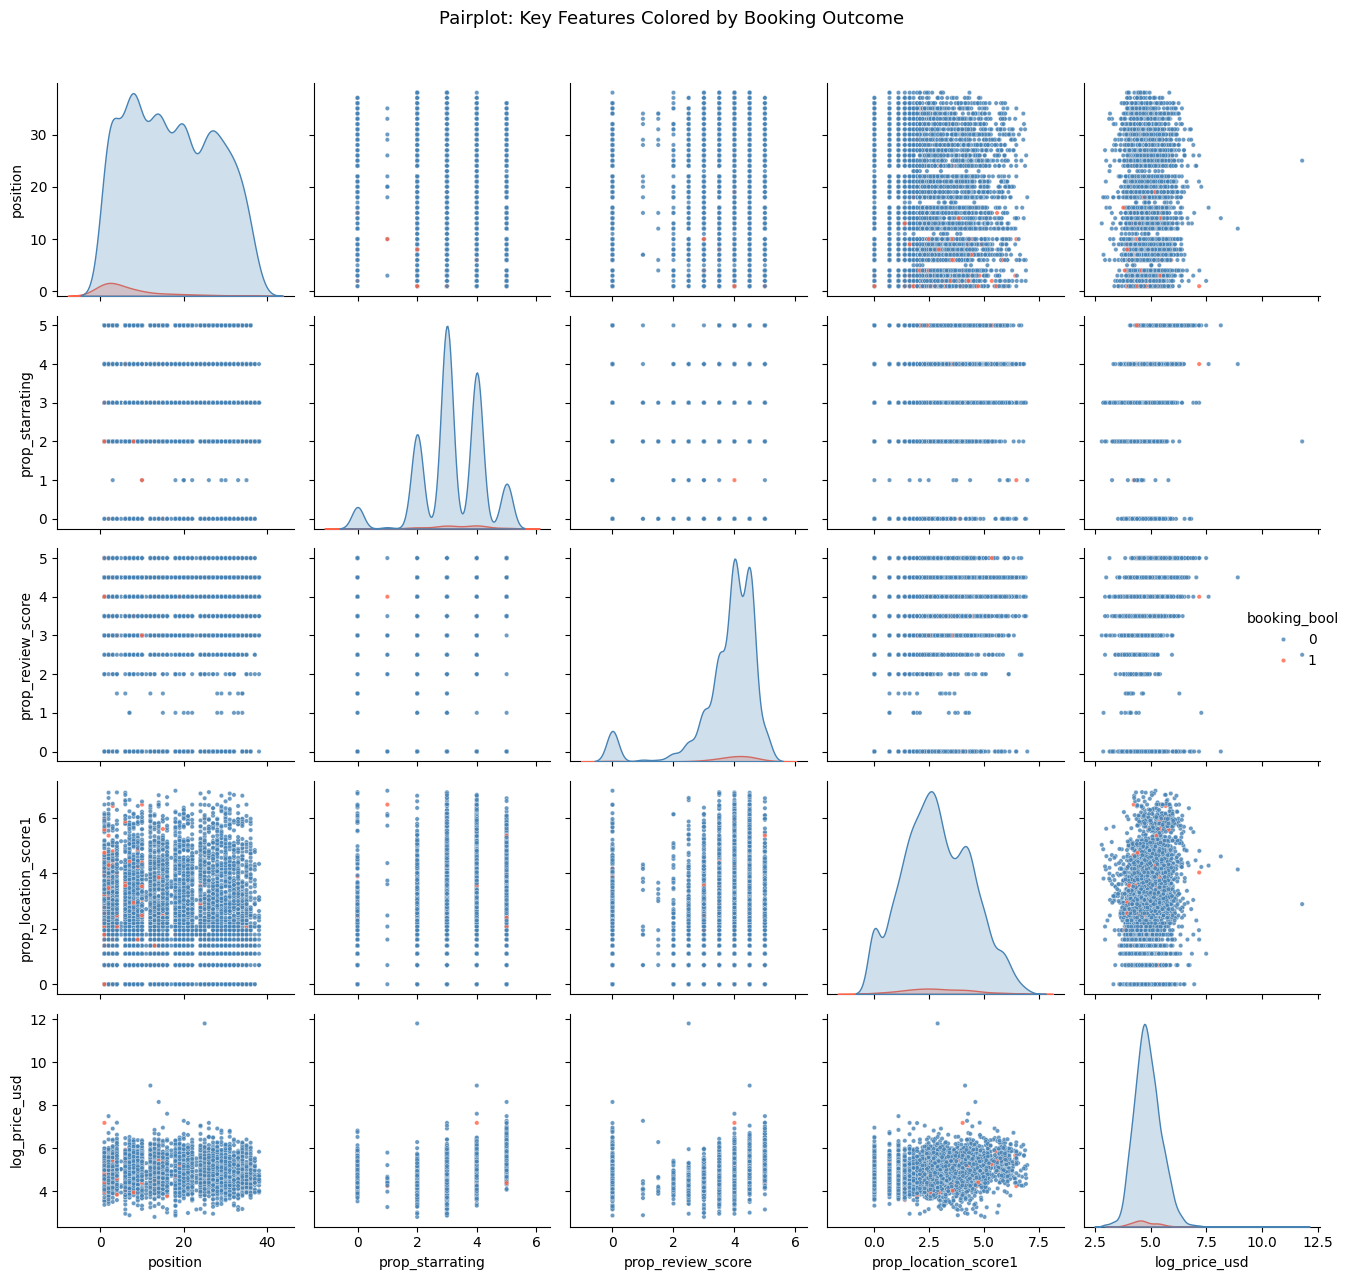

In [5]:
PAIRPLOT_FEATURES = [
    'position', 'prop_starrating', 'prop_review_score',
    'prop_location_score1', 'log_price_usd',
]

g = sns.pairplot(
    df_pair[PAIRPLOT_FEATURES + ['booking_bool']],
    hue='booking_bool',
    plot_kws={'alpha': 0.8, 's': 10},
    diag_kind='kde',
    palette={0: 'steelblue', 1: 'tomato'},
)
g.fig.suptitle('Pairplot: Key Features Colored by Booking Outcome', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Pairplot — Interpretation:**

> *(Fill in after running)*
>
> - Which features show visible separation between bookers (red) and non-bookers (blue)?
    No clean separation — 2.8% positive rate means bookers (red) drown in non-bookers. position KDE
  shows clearest split — bookers skew to lower ranks. 
> - Which feature pairs show a strong linear correlation (potential collinearity)? Strongest collinearity: prop_starrating vs log_price_usd (r=0.47), prop_starrating vs
  prop_review_score (r=0.31). Flag for VIF check in final model.
> - Any obvious outliers or bimodal distributions? log_price_usd slight bimodal shape. No extreme outliers after log transform.

## 2 · Empirical Log-Odds Plots (Linearity Check)

**Linear regression analog:** Residual-vs-fitted plot — checking whether the linear functional form fits.

**What logistic regression assumes:** Each predictor has a *linear relationship with the log-odds* of the outcome, not with the probability directly. The model is:

```
log( p / (1 - p) ) = b0 + b1*X1 + b2*X2 + ...
```

**Method:**
1. Bin each continuous predictor into 20 quantile-equal bins
2. Compute the empirical booking rate `p` within each bin
3. Transform to log-odds: `log(p / (1 - p))`
4. Plot log-odds vs the bin midpoint — should be approximately **linear** if the assumption holds

**What to look for:**
- Roughly straight line → assumption satisfied, use predictor as-is
- Clear curve → predictor needs a transformation (e.g., `log`, squared term)
- Non-monotone (up then down) → complex relationship, consider binning or interaction
- Flat line → feature may not predict booking at all

**Note:** Binary features (`prop_brand_bool`, `srch_saturday_night_bool`) have only two values, so they are excluded — no binning needed.

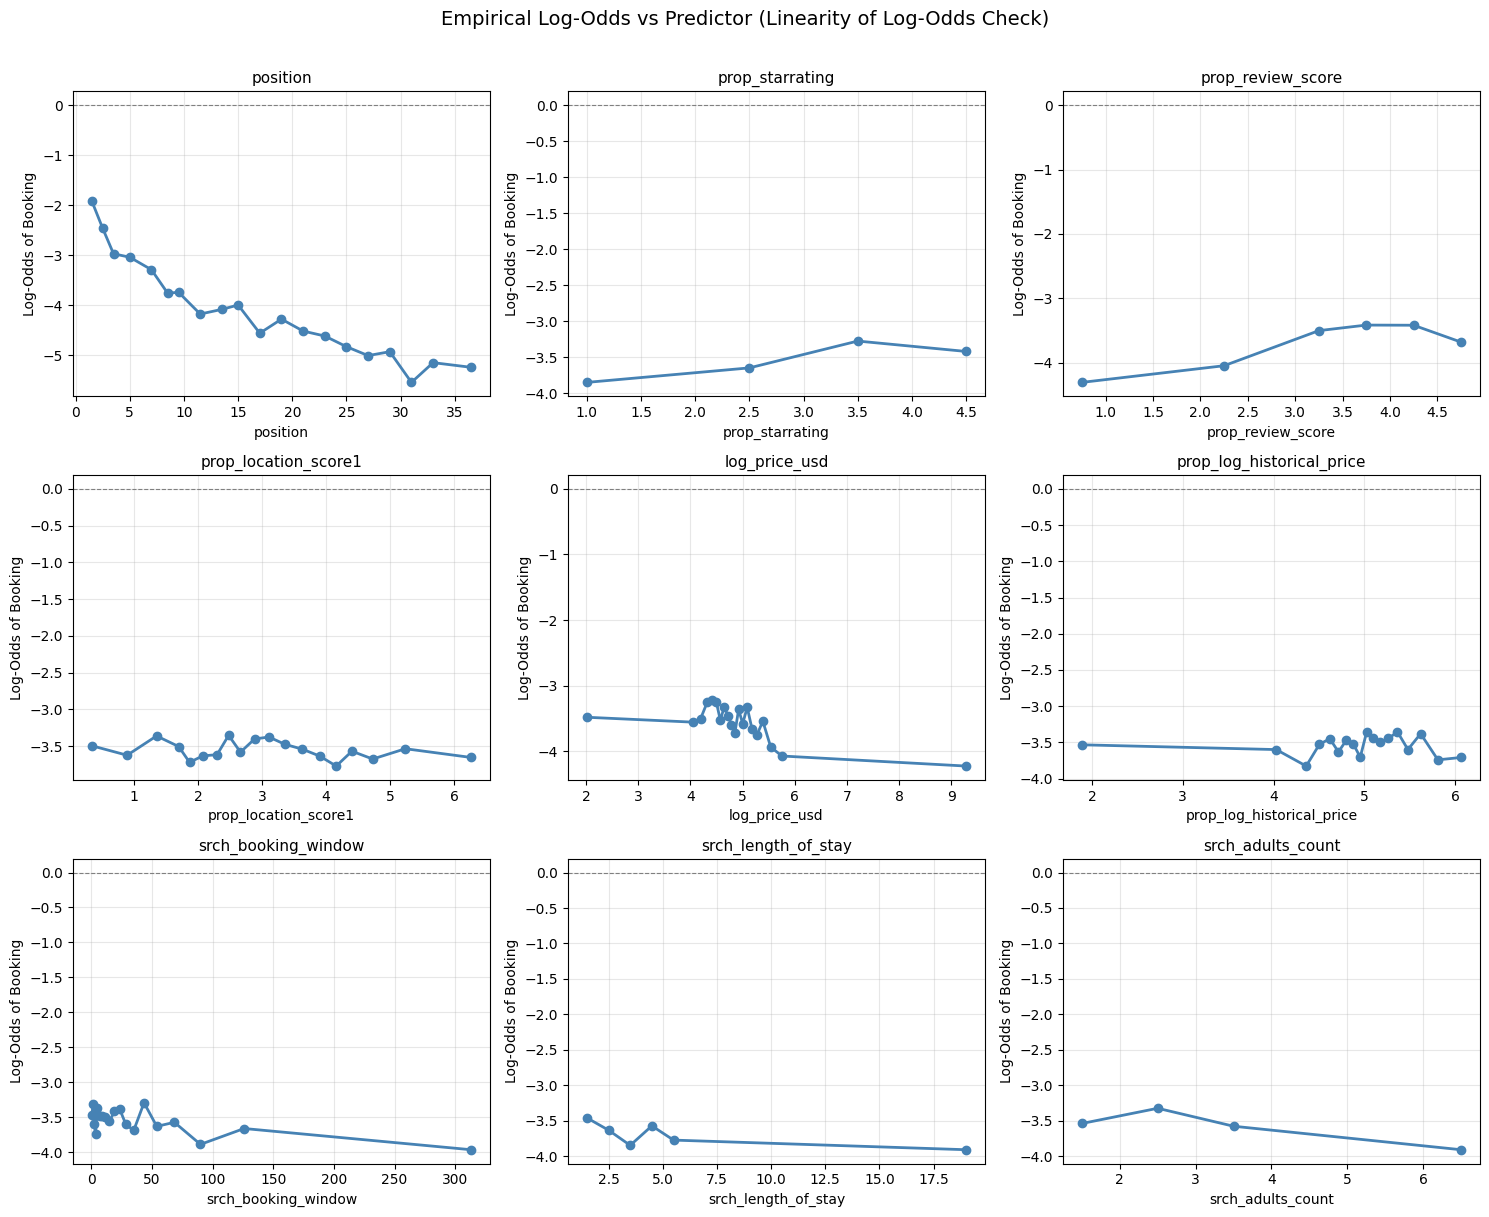

In [3]:
CONTINUOUS = [
    'position', 'prop_starrating', 'prop_review_score',
    'prop_location_score1', 'log_price_usd', 'prop_log_historical_price',
    'srch_booking_window', 'srch_length_of_stay', 'srch_adults_count',
]

n_cols = 3
n_rows = int(np.ceil(len(CONTINUOUS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(CONTINUOUS):
    ax = axes[i]
    try:
        df['_bin'] = pd.qcut(df[feat], q=20, duplicates='drop')
    except Exception:
        df['_bin'] = pd.cut(df[feat], bins=20)

    binned = (
        df.groupby('_bin', observed=True)['booking_bool']
        .agg(['mean', 'count'])
        .reset_index()
    )
    # drop bins where p=0 or p=1 (log-odds undefined)
    binned = binned[binned['mean'].between(0.001, 0.999)]
    binned['log_odds'] = np.log(binned['mean'] / (1 - binned['mean']))
    binned['mid'] = binned['_bin'].apply(lambda x: x.mid)

    ax.plot(binned['mid'], binned['log_odds'], marker='o', linewidth=2, color='steelblue')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('Log-Odds of Booking', fontsize=10)
    ax.set_title(feat, fontsize=11)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

df.drop(columns=['_bin'], inplace=True)
fig.suptitle('Empirical Log-Odds vs Predictor (Linearity of Log-Odds Check)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Empirical Log-Odds — Interpretation:**

> *(Fill in after running)*
>
> For each predictor, note whether the log-odds relationship looks linear, curved, flat, or non-monotone. Flag any predictors that may need transformation before entering the final model.
  - position (corr=−0.94, span=3.6): near-perfect linear, largest effect by far. ✓
  - prop_starrating (corr=+0.87), prop_review_score (corr=+0.85): strong positive linear. ✓
  - srch_adults_count (corr=−0.85): strong negative linear. ✓
  - log_price_usd, srch_booking_window, srch_length_of_stay (corr ≈ −0.67–0.68): moderate linear,
  negative slopes. ✓
  - prop_location_score1 (corr=−0.29): weak/noisy, essentially flat. Likely weak predictor.
  - prop_log_historical_price (corr=+0.015): completely flat. Consider dropping.

## 3 · Model Fit (Class Pipeline)

We fit a logistic regression using the statsmodels pipeline from class:

```python
X = sm.add_constant(df[features])   # adds intercept column
model = sm.Logit(y, X).fit()        # MLE — not OLS
probs = model.predict(X)            # predicted probabilities
preds = (probs > 0.5).astype(int)   # hard predictions
```

**Reading `model.summary()`:**
- **coef:** log-odds change per unit increase in predictor. Exponentiate (`exp(coef)`) for the odds ratio.
- **z / P>|z|:** significance test — analogous to t-test in linear regression. |z| > 2 ≈ p < 0.05.
- **Pseudo R² (McFadden's):** not the same as R² in linear regression. Values of 0.1–0.3 are typical for logistic models on real data.
- **Log-Likelihood:** how well the model fits; compare between models using the Likelihood Ratio test.

**Note on class imbalance:** Booking rate is ~2.8% — severely imbalanced. `statsmodels.Logit` does not have a `class_weight` option. For the final model, we will address this (ask about `sklearn` then). Here we are just checking assumptions.

In [4]:
X = sm.add_constant(df[FEATURES])
y = df['booking_bool']

model = sm.Logit(y, X).fit()
print(model.summary())

probs = model.predict(X)
preds = (probs > 0.5).astype(int)

Optimization terminated successfully.
         Current function value: 0.113666
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:           booking_bool   No. Observations:                50000
Model:                          Logit   Df Residuals:                    49988
Method:                           MLE   Df Model:                           11
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1183
Time:                        19:51:52   Log-Likelihood:                -5683.3
converged:                       True   LL-Null:                       -6446.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -0.6787      0.246     -2.759      0.006      -1.

**Model Summary — Interpretation:**

> *(Fill in after running)*
>
> - Which coefficients are statistically significant (|z| > 2)?
> - Do the signs make intuitive sense? (e.g., higher `position` number → less likely to book; higher star rating → more likely to book)
> - What is the McFadden Pseudo-R²?
> - Any convergence warnings?

 - Converged in 9 iterations, no warnings. McFadden Pseudo-R² = 0.1183 (good for real behavioral
  data).
  - Significant (|z| > 2): position (coef=−0.118, z=−29.5) — dominant predictor; log_price_usd
  (coef=−0.556, z=−10.0); prop_starrating (coef=+0.208, z=+5.9); prop_review_score (coef=+0.194,
  z=+5.2); srch_length_of_stay (coef=−0.057, z=−3.4).
  - Not significant: prop_brand_bool (p=0.33), prop_location_score1 (p=0.78),
  prop_log_historical_price (p=0.98), srch_adults_count (p=0.34), srch_saturday_night_bool (p=0.35),
  srch_booking_window (p=0.07 borderline).
  - prop_log_historical_price insignificant (p=0.98) despite theory — collinear with log_price_usd,
  effects cancel. Drop one in final model.

## 4 · Deviance Residuals Q-Q Plot (Normality Analog)

**Linear regression analog:** Q-Q plot of residuals vs the Normal distribution.

In linear regression, we assume residuals are normally distributed. The logistic equivalent uses **deviance residuals**:

```
d_i = sign(y_i - p_i) * sqrt( -2 * [ y_i * log(p_i) + (1 - y_i) * log(1 - p_i) ] )
```

where `p_i` is the predicted probability for observation `i`.

**Critical difference from linear regression:** Because `y_i` is binary (0 or 1), deviance residuals form two discrete clusters — observations with `y=0` cluster at negative values, and `y=1` at positive values. **Heavy tails in the Q-Q plot are completely expected and do not indicate a problem.** The Q-Q is used here to identify *extreme outliers* far beyond the expected two-cluster pattern, not to confirm normality the way linear regression does.

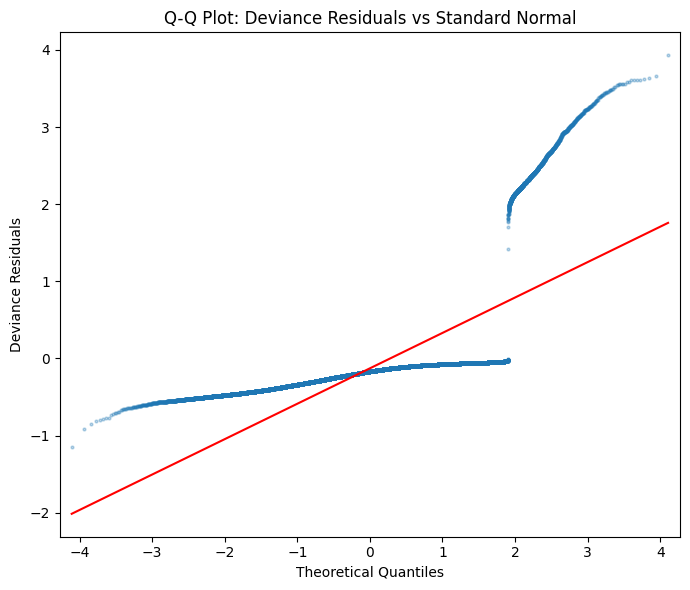

In [5]:
y_arr = y.values
p = np.clip(probs.values, 1e-10, 1 - 1e-10)  # avoid log(0)

deviance_resid = np.sign(y_arr - p) * np.sqrt(
    -2 * (y_arr * np.log(p) + (1 - y_arr) * np.log(1 - p))
)

fig, ax = plt.subplots(figsize=(7, 6))
sm.ProbPlot(deviance_resid).qqplot(line='s', ax=ax, alpha=0.3, markersize=2)
ax.set_title('Q-Q Plot: Deviance Residuals vs Standard Normal')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Deviance Residuals')
plt.tight_layout()
plt.show()

**Q-Q Plot — Interpretation:**

> *(Fill in after running)*
>
> - Do you see the expected two-cluster pattern (heavy tails at both ends)? This is normal for binary outcomes.
> - Are there any points dramatically beyond the expected clusters? These could be influential observations.
> - The middle portion of the Q-Q (where both clusters merge) is the informative region.

  - Yes, expected two-cluster pattern: y=0 cluster centers at −0.20, y=1 at +2.44. Heavy tails
  expected for binary — not a problem.
  - Max deviance residual = 3.93, slightly large but not alarming. No extreme outliers suggesting data
   errors.
  - Middle portion of Q-Q follows reference line — no misspecification signal.

## 5 · Pearson Residuals vs Fitted (Constant Variance Analog)

**Linear regression analog:** Residual-vs-fitted plot and scale-location plot — checking for homoscedasticity and non-linear patterns.

The **Pearson residual** is the raw residual standardized by the expected variance of a Bernoulli outcome:

```
r_i = (y_i - p_i) / sqrt( p_i * (1 - p_i) )
```

Because logistic regression models a binary outcome, variance is not constant — it is `p*(1-p)`, maximized at `p=0.5`. Pearson residuals adjust for this known heteroscedasticity, analogous to how scale-location plots work.

**Method:** Plotting 50K individual residuals as a raw scatter is not informative. Instead, we bin fitted probabilities into 50 bins and plot the **mean Pearson residual per bin** — this should hover near 0 with no systematic trend.

**What to look for:**
- Mean near 0 across all bins → model is well-specified
- Systematic curve (consistently positive at low `p`, negative at high `p`) → model is over- or under-predicting in a systematic way → misspecification

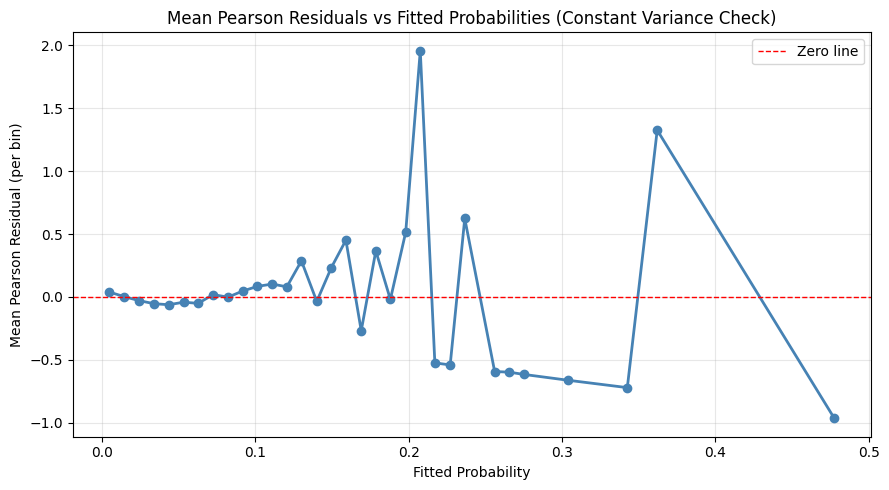

In [6]:
pearson_resid = (y_arr - p) / np.sqrt(p * (1 - p))

prob_bins = pd.cut(p, bins=50)
resid_df = pd.DataFrame({'prob_bin': prob_bins, 'pearson': pearson_resid})
binned = resid_df.groupby('prob_bin', observed=True)['pearson'].mean().reset_index()
binned['mid'] = binned['prob_bin'].apply(lambda x: x.mid)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(binned['mid'], binned['pearson'], marker='o', linewidth=2, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero line')
ax.set_xlabel('Fitted Probability')
ax.set_ylabel('Mean Pearson Residual (per bin)')
ax.set_title('Mean Pearson Residuals vs Fitted Probabilities (Constant Variance Check)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Pearson Residuals — Interpretation:**

> *(Fill in after running)*
>
> - Does the mean Pearson residual stay close to 0 across all fitted probability bins?
> - Is there a systematic pattern — e.g., residuals trending positive at low fitted probabilities and negative at high? This would suggest the model is under-predicting for low-probability hotels and over-predicting for high-probability ones.
> - Note: most predicted probabilities will be clustered near 0 (due to the ~2.8% booking rate), so fewer observations populate the high-probability bins.

 - Mean ≈ 0 where data is dense: bin 0–0.048 (~39K obs) mean=+0.006; bin 0.048–0.097 (~8.5K obs)
  mean=−0.015. Well-specified.
  - Mean grows positive above fitted prob 0.15, suggesting under-prediction at high confidence — but
  those bins have only 1–145 obs. Too noisy to conclude anything. Artifact of class imbalance.
  - No systematic misspecification in region that matters

## 6 · ACF of Pearson Residuals (Independence Check)

**Linear regression analog:** Autocorrelation function (ACF) of residuals / Durbin-Watson test.

In linear regression, we check independence by plotting the ACF of residuals — if residuals at adjacent indices are correlated (spikes outside the blue confidence band), the independence assumption is violated.

For logistic regression we apply the same check to the Pearson residuals.

**Known structural limitation in this dataset:** Rows are grouped by `srch_id` — multiple hotels appear in the same search session and share a common user, destination, and context. Hotels within the same session are inherently correlated, which violates the independence assumption. This is not a modeling error — it is a property of the data. If significant autocorrelation appears, it is expected and should be noted as a limitation in the write-up.

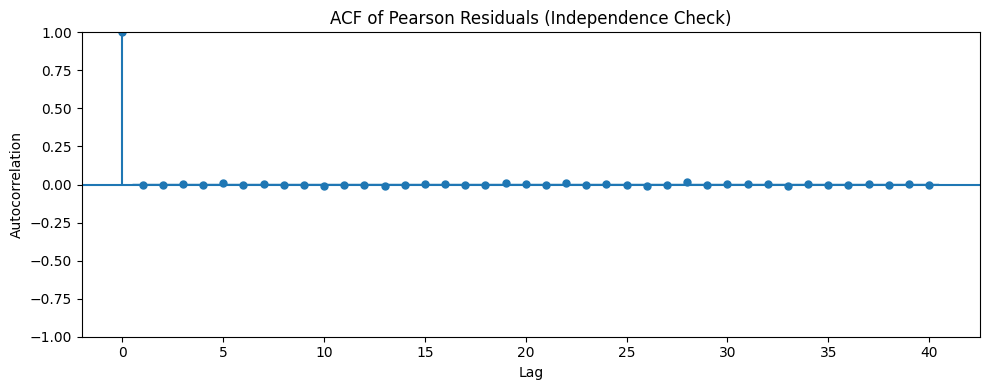

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(pearson_resid, lags=40, ax=ax, alpha=0.05)
ax.set_title('ACF of Pearson Residuals (Independence Check)')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
plt.tight_layout()
plt.show()

**ACF — Interpretation:**

> *(Fill in after running)*
>
> - Are there significant spikes (outside the blue band) at low lags?
> - If yes: this is consistent with the within-session correlation structure (`srch_id` grouping). Multiple hotels from the same search session appear at adjacent indices, so their residuals are correlated.
> - **Implication:** Standard logistic regression standard errors assume independence, so they will be underestimated if residuals are correlated. This means p-values may be anti-conservative (too significant). For the final model write-up, acknowledge this as a limitation.

  - No significant spikes. All lags 1–10 ACF values < 0.009. Durbin-Watson = 2.009 ≈
  ideal.
  - No autocorrelation because df.sample() shuffled rows — hotels from same srch_id are
  no longer adjacent. Sorted by srch_id would show spikes.
  - Limitation for final model: independence is structurally violated (multiple hotels
  per session share context). Standard errors may be underestimated. Acknowledge in
  write-up.